In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from homeomorphism.hooks import list_module_names, get_submodule, get_submodules, get_modules, register_forward_capture_hooks
from homeomorphism.jacobian import submodule_output_jacobian

In [3]:
model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [4]:
cache = {}
modules = get_modules(model, ["attn"])
handles = register_forward_capture_hooks(modules, cache, "attn")

_ = model(**tokenizer("Hello what's up", return_tensors="pt"))

print(cache.keys())           # dict_keys(["attn_0", "attn_1", ...])
print(cache["attn_0"].shape)  # tensor shape for first hooked module

# remove_hooks(handles)

dict_keys(['attn_0', 'attn_1', 'attn_2', 'attn_3', 'attn_4', 'attn_5', 'attn_6', 'attn_7', 'attn_8', 'attn_9', 'attn_10', 'attn_11'])
torch.Size([1, 4, 768])


In [15]:
inputs = tokenizer("Hello my name is Preslav", return_tensors="pt")
jac = submodule_output_jacobian(
    model,
    "transformer.h.2.attn",
    inputs,
    input_index=0,
    batch_index=0,
    vectorize=True,
 )

print(jac.shape)

torch.Size([1, 6, 768, 1, 6, 768])


In [20]:
jac[0,-3,:,0,-1,:]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
import torch
from transformers import AutoModelForCausalLM

# Load GPT-2 and access its token embedding matrix: [vocab_size, hidden_size]
model = AutoModelForCausalLM.from_pretrained("gpt2")
embedding_matrix = model.transformer.wte.weight.detach()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

torch.Size([50257, 768])
embedding_matrix shape: (50257, 768)
summed shape: (50257,)


tensor([ 0.3766,  3.4404,  2.0287,  ...,  0.1466, -0.7530, -0.2386])

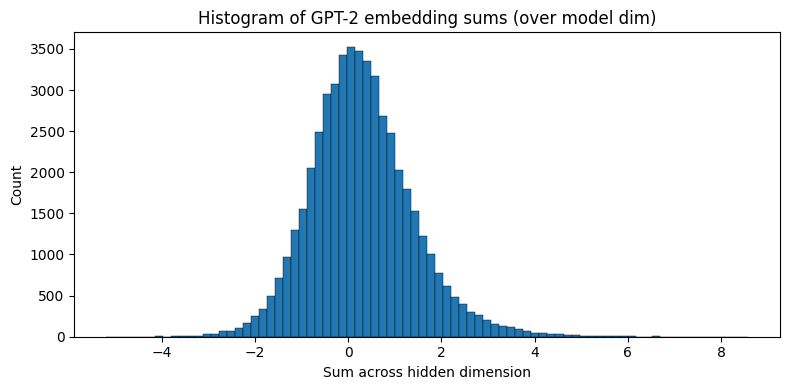

In [27]:
import matplotlib.pyplot as plt

vals = embedding_sum_over_model_dim.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.hist(vals, bins=80, edgecolor="black", linewidth=0.3)
# plt.yscale("log")
plt.title("Histogram of GPT-2 embedding sums (over model dim)")
plt.xlabel("Sum across hidden dimension")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [46]:
# SVD of the centered embedding matrix
# centerned_matrix shape: [vocab_size, hidden_size]
U, S, Vh = torch.linalg.svd(centerned_matrix, full_matrices=False)
centerned_matrix
print("U shape:", tuple(U.shape))
print("S shape:", tuple(S.shape))
print("Vh shape:", tuple(Vh.shape))


U shape: (50257, 768)
S shape: (768,)
Vh shape: (768, 768)


In [47]:
print(S)

tensor([1.0296e+02, 6.9417e+01, 6.4779e+01, 6.3426e+01, 6.1879e+01, 5.9832e+01,
        5.7434e+01, 5.6705e+01, 5.5320e+01, 5.3848e+01, 5.3599e+01, 5.2807e+01,
        5.2512e+01, 5.1934e+01, 5.1004e+01, 5.0433e+01, 5.0117e+01, 4.9499e+01,
        4.8916e+01, 4.8089e+01, 4.7719e+01, 4.7341e+01, 4.6612e+01, 4.6494e+01,
        4.6270e+01, 4.5682e+01, 4.5472e+01, 4.5098e+01, 4.4859e+01, 4.4713e+01,
        4.4328e+01, 4.4068e+01, 4.3740e+01, 4.3452e+01, 4.3340e+01, 4.3137e+01,
        4.3067e+01, 4.2994e+01, 4.2676e+01, 4.2644e+01, 4.2310e+01, 4.2106e+01,
        4.1923e+01, 4.1762e+01, 4.1563e+01, 4.1478e+01, 4.1320e+01, 4.1267e+01,
        4.1074e+01, 4.0961e+01, 4.0801e+01, 4.0594e+01, 4.0576e+01, 4.0443e+01,
        4.0331e+01, 4.0265e+01, 4.0195e+01, 4.0115e+01, 3.9914e+01, 3.9766e+01,
        3.9696e+01, 3.9526e+01, 3.9398e+01, 3.9307e+01, 3.9199e+01, 3.9184e+01,
        3.9120e+01, 3.9075e+01, 3.8989e+01, 3.8901e+01, 3.8801e+01, 3.8784e+01,
        3.8611e+01, 3.8588e+01, 3.8434e+

In [49]:
torch.sum(Vh[0]*centerned_matrix, dim=1)

tensor([ 1.2710,  1.3960,  0.8194,  ..., -0.5017, -0.3092,  1.2849])

In [61]:
import torch.nn as nn

if "model" not in globals() or getattr(getattr(model, "config", None), "model_type", None) != "gpt2":
    from transformers import AutoModelForCausalLM
    model = AutoModelForCausalLM.from_pretrained("gpt2")

layernorm_gamma_maxabs = []
for module_name, module in model.named_modules():
    if isinstance(module, nn.LayerNorm) and module.weight is not None:
        max_abs_value = module.weight.detach().abs().max().item()
        layernorm_gamma_maxabs.append((module_name, max_abs_value))

print("[('module_path', max_abs_gamma), ...]")
for module_name, max_abs_value in layernorm_gamma_maxabs:
    print(f"({module_name!r}, {max_abs_value})")

# layernorm_gamma_maxabs

[('module_path', max_abs_gamma), ...]
('transformer.h.0.ln_1', 0.25266674160957336)
('transformer.h.0.ln_2', 1.5110347270965576)
('transformer.h.1.ln_1', 0.6553342938423157)
('transformer.h.1.ln_2', 0.4522954523563385)
('transformer.h.2.ln_1', 0.9443219900131226)
('transformer.h.2.ln_2', 0.729613184928894)
('transformer.h.3.ln_1', 0.7676699757575989)
('transformer.h.3.ln_2', 1.1604341268539429)
('transformer.h.4.ln_1', 0.6704616546630859)
('transformer.h.4.ln_2', 1.1321852207183838)
('transformer.h.5.ln_1', 0.7687034010887146)
('transformer.h.5.ln_2', 1.4179682731628418)
('transformer.h.6.ln_1', 0.7796484231948853)
('transformer.h.6.ln_2', 1.3398431539535522)
('transformer.h.7.ln_1', 0.8182540535926819)
('transformer.h.7.ln_2', 1.292971134185791)
('transformer.h.8.ln_1', 0.9247856140136719)
('transformer.h.8.ln_2', 1.072196125984192)
('transformer.h.9.ln_1', 0.9449954032897949)
('transformer.h.9.ln_2', 0.9475935101509094)
('transformer.h.10.ln_1', 0.9213718175888062)
('transformer.h.10

In [4]:
from transformers import AutoModelForCausalLM

llama_model_name = "google/gemma-3-1b-pt"
llama_model = AutoModelForCausalLM.from_pretrained(
    llama_model_name,
    low_cpu_mem_usage=True,
)

llama_norm_gamma_maxabs = []
for module_name, module in llama_model.named_modules():
    has_gamma = hasattr(module, "weight") and module.weight is not None
    is_norm = module.__class__.__name__ in {"LayerNorm", "LlamaRMSNorm", "RMSNorm"}
    if has_gamma and is_norm:
        max_abs_value = module.weight.detach().abs().max().item()
        llama_norm_gamma_maxabs.append((module_name, max_abs_value))

print(f"Model: {llama_model_name}")
print("[('module_path', max_abs_gamma), ...]")
for module_name, max_abs_value in llama_norm_gamma_maxabs:
    print(f"({module_name!r}, {max_abs_value})")

config.json:   0%|          | 0.00/880 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Model: google/gemma-3-1b-pt
[('module_path', max_abs_gamma), ...]


In [5]:
gemma_model = llama_model

gemma_norm_gamma_maxabs = []
for module_name, module in gemma_model.named_modules():
    has_gamma = hasattr(module, "weight") and module.weight is not None
    cls_name = module.__class__.__name__.lower()
    is_norm = "norm" in cls_name
    if has_gamma and is_norm:
        max_abs_value = module.weight.detach().abs().max().item()
        gemma_norm_gamma_maxabs.append((module_name, max_abs_value))

print(f"Model: {llama_model_name}")
print(f"Total norm modules: {len(gemma_norm_gamma_maxabs)}")
print("[('module_path', max_abs_gamma), ...]")
for module_name, max_abs_value in gemma_norm_gamma_maxabs:
    print(f"({module_name!r}, {max_abs_value})")

Model: google/gemma-3-1b-pt
Total norm modules: 157
[('module_path', max_abs_gamma), ...]
('model.layers.0.self_attn.q_norm', 1.8984375)
('model.layers.0.self_attn.k_norm', 6.4375)
('model.layers.0.input_layernorm', 37.5)
('model.layers.0.post_attention_layernorm', 73.0)
('model.layers.0.pre_feedforward_layernorm', 33.0)
('model.layers.0.post_feedforward_layernorm', 105.5)
('model.layers.1.self_attn.q_norm', 2.65625)
('model.layers.1.self_attn.k_norm', 6.59375)
('model.layers.1.input_layernorm', 44.75)
('model.layers.1.post_attention_layernorm', 75.5)
('model.layers.1.pre_feedforward_layernorm', 48.25)
('model.layers.1.post_feedforward_layernorm', 60.75)
('model.layers.2.self_attn.q_norm', 8.3125)
('model.layers.2.self_attn.k_norm', 34.0)
('model.layers.2.input_layernorm', 58.75)
('model.layers.2.post_attention_layernorm', 51.25)
('model.layers.2.pre_feedforward_layernorm', 34.75)
('model.layers.2.post_feedforward_layernorm', 156.0)
('model.layers.3.self_attn.q_norm', 3.421875)
('model

In [6]:
gemma_norm_gamma_sorted = sorted(gemma_norm_gamma_maxabs, key=lambda x: x[1], reverse=True)
print("Top 25 by max_abs_gamma:")
for module_name, max_abs_value in gemma_norm_gamma_sorted[:25]:
    print(f"({module_name!r}, {max_abs_value})")

Top 25 by max_abs_gamma:
('model.layers.24.post_feedforward_layernorm', 844.0)
('model.layers.25.post_feedforward_layernorm', 696.0)
('model.layers.23.post_feedforward_layernorm', 536.0)
('model.layers.7.post_feedforward_layernorm', 430.0)
('model.layers.23.post_attention_layernorm', 398.0)
('model.layers.9.post_feedforward_layernorm', 344.0)
('model.layers.10.post_feedforward_layernorm', 330.0)
('model.layers.6.post_feedforward_layernorm', 320.0)
('model.layers.11.post_feedforward_layernorm', 290.0)
('model.layers.22.post_feedforward_layernorm', 284.0)
('model.layers.17.post_feedforward_layernorm', 266.0)
('model.layers.25.post_attention_layernorm', 254.0)
('model.layers.18.post_feedforward_layernorm', 251.0)
('model.layers.4.post_feedforward_layernorm', 248.0)
('model.layers.5.post_feedforward_layernorm', 246.0)
('model.layers.8.post_feedforward_layernorm', 243.0)
('model.layers.21.post_feedforward_layernorm', 231.0)
('model.layers.16.post_feedforward_layernorm', 229.0)
('model.layer